# Death of the Starter House — saved Zillow exploration

**Status: exploratory notebook imported on October 5, 2026; full source-backed rerun pending.**

The version 1 question remains: how have Kansas City's bottom-tier home values changed since 2000 compared with St. Louis, Indianapolis, and the U.S., including the period after April 2013? The retained Zillow work below covers Kansas City only. Peer comparisons, indexed growth, common-endpoint annualized changes, and January 2013 / January 2014 sensitivity checks are **pending**, not completed findings.

Saved outputs come from `01_data_exploration.ipynb` (Python 3.12.4, pandas 2.2.2). The publishing review checked Kansas City dates and selected arithmetic against the 320 values embedded in its saved Plotly output; it did not reload the original CSV or verify its series settings. See [source provenance](../docs/source_provenance.md) and [analysis plan](../docs/analysis_plan.md).

Run from the repository root or `notebooks/`, with the original snapshot at `data/raw/zillow/2026-10-01/zillow_bottom_tier_metro.csv` (or `data/raw/zillow_bottom_tier_metro.csv`). The dated folder is a recorded path, not proof of the retrieval date. Raw data remain outside Git.

## Version 1: Kansas City Zillow exploration

Values are nominal USD. April 2013 is an exploratory reference month, not a tested structural break or a causal explanation. Saved outputs are historical outputs; they do not establish a successful run of this packaged copy.


In [ ]:
import sys
from pathlib import Path
import pandas as pd

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)


In [ ]:
# Support launching Jupyter from the repository root or notebooks/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "README.md").is_file() else cwd.parent
assert (PROJECT_ROOT / "README.md").is_file(), "Run from the repository root or notebooks/."

snapshot = PROJECT_ROOT / "data" / "raw" / "zillow" / "2026-10-01" / "zillow_bottom_tier_metro.csv"
flat_snapshot = PROJECT_ROOT / "data" / "raw" / "zillow_bottom_tier_metro.csv"
DATA_FILE = snapshot if snapshot.is_file() else flat_snapshot
assert DATA_FILE.is_file(), "Place the original Zillow snapshot in the documented data/raw path."
RAW_DIR = DATA_FILE.parent


In [4]:
df = pd.read_csv(DATA_FILE)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

Rows: 892
Columns: 325


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31,2026-08-31
0,102001,0,United States,country,NaN,59744.950243,59837.948509,59955.308175,60214.698178,60521.676256,...,196958.023190,197541.112500,198307.905194,199151.438659,199850.321072,200153.446692,200138.376598,200111.194000,200228.030325,200549.856769
1,394913,1,"New York, NY",msa,NY,119605.523151,120075.170119,120534.628345,121488.095363,122487.363111,...,471615.068079,473954.134066,476060.818090,478531.659836,480966.535741,482504.228454,483546.787447,484710.846267,486788.293351,489359.338147
2,753899,2,"Los Angeles, CA",msa,CA,128061.465755,128443.552097,129042.260821,130231.701240,131582.498172,...,660718.623359,663161.615803,664727.329989,665302.255717,664428.320544,662686.113786,661081.538625,659725.245514,659496.793626,660004.753787
3,394463,3,"Chicago, IL",msa,IL,80420.148039,80492.473924,80634.061816,80961.865400,81355.425754,...,221095.527644,222145.527908,223262.709342,224570.114241,225658.474563,226385.985864,226812.246630,227425.998854,228423.258119,229682.381274
4,394514,4,"Dallas, TX",msa,TX,69622.092877,69642.680430,69656.651053,69727.920177,69847.910364,...,251382.507954,251322.837213,251412.807368,251456.693309,251106.224882,250364.021741,249366.193163,248511.187835,248039.871737,248043.002535


In [5]:
kc = df.loc[
    df["RegionName"].str.contains("Kansas City", case=False, na=False)
    & df["RegionType"].eq("msa")
].copy()

display(kc[["RegionID", "RegionName", "RegionType", "StateName"]])

assert len(kc) == 1, "Expected exactly one Kansas City metro row."

,RegionID,RegionName,RegionType,StateName
31,394735,"Kansas City, MO",msa,MO


In [6]:
# Identify columns named like dates: YYYY-MM-DD.
date_columns = df.columns[
    df.columns.str.fullmatch(r"\d{4}-\d{2}-\d{2}")
].tolist()

kc_monthly = kc.melt(
    id_vars=["RegionID", "RegionName"],
    value_vars=date_columns,
    var_name="date",
    value_name="bottom_tier_zhvi"
)

kc_monthly["date"] = pd.to_datetime(kc_monthly["date"])
kc_monthly = kc_monthly.sort_values("date").reset_index(drop=True)

display(kc_monthly.head())
display(kc_monthly.tail())

,RegionID,RegionName,date,bottom_tier_zhvi
0,394735,"Kansas City, MO",2000-01-31,50333.788550
1,394735,"Kansas City, MO",2000-02-29,50372.725666
2,394735,"Kansas City, MO",2000-03-31,50462.314432
3,394735,"Kansas City, MO",2000-04-30,50649.859576
4,394735,"Kansas City, MO",2000-05-31,50917.236482


,RegionID,RegionName,date,bottom_tier_zhvi
315,394735,"Kansas City, MO",2026-04-30,195274.605021
316,394735,"Kansas City, MO",2026-05-31,195391.425682
317,394735,"Kansas City, MO",2026-06-30,195692.513875
318,394735,"Kansas City, MO",2026-07-31,196274.288419
319,394735,"Kansas City, MO",2026-08-31,197211.322812


In [7]:
print("Monthly rows:", len(kc_monthly))
print("First month:", kc_monthly["date"].min().date())
print("Last month:", kc_monthly["date"].max().date())
print("Missing values:", kc_monthly["bottom_tier_zhvi"].isna().sum())
print("Duplicate months:", kc_monthly["date"].duplicated().sum())

Monthly rows: 320
First month: 2000-01-31
Last month: 2026-08-31
Missing values: 0
Duplicate months: 0


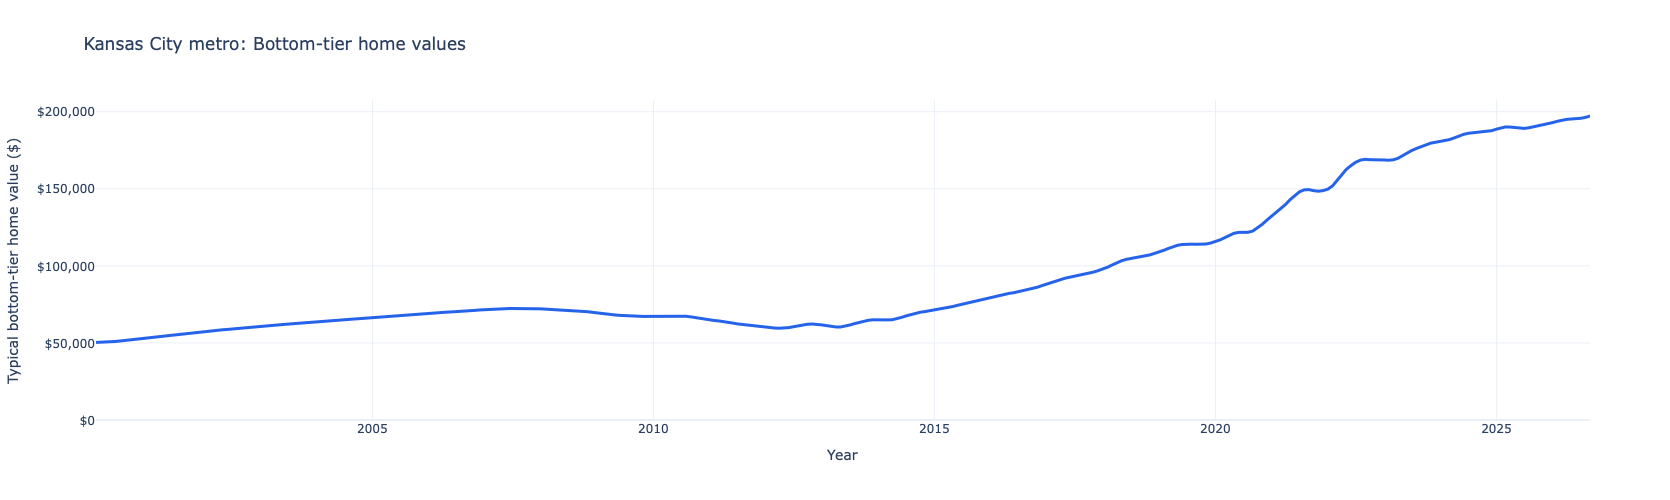

In [8]:
import plotly.express as px

fig = px.line(
    kc_monthly,
    x="date",
    y="bottom_tier_zhvi",
    title="Kansas City metro: Bottom-tier home values",
    labels={
        "date": "Year",
        "bottom_tier_zhvi": "Typical bottom-tier home value ($)"
    },
    template="plotly_white"
)

fig.update_traces(
    line_color="#2563EB",
    line_width=3,
    hovertemplate="%{x|%b %Y}<br>$%{y:,.0f}<extra></extra>"
)

fig.update_layout(
    height=500,
    yaxis_tickprefix="$",
    yaxis_tickformat=",",
    yaxis_rangemode="tozero"
)

fig.show()

In [9]:
# Examine the period around the apparent turning point.
turning_point = kc_monthly.loc[
    kc_monthly["date"].between("2011-01-01", "2014-12-31")
].copy()

lowest = turning_point.loc[
    turning_point["bottom_tier_zhvi"].idxmin()
]

print(
    f"Lowest value during 2011–2014: "
    f"${lowest['bottom_tier_zhvi']:,.0f} "
    f"in {lowest['date']:%B %Y}"
)

# Inspect the months surrounding April 2013 observation.
display(
    turning_point.loc[
        turning_point["date"].between("2013-01-01", "2013-07-31"),
        ["date", "bottom_tier_zhvi"]
    ].round({"bottom_tier_zhvi": 0})
)

Lowest value during 2011–2014: $59,537 in March 2012


,date,bottom_tier_zhvi
156,2013-01-31,61216.0
157,2013-02-28,60736.0
158,2013-03-31,60357.0
159,2013-04-30,60324.0
160,2013-05-31,60824.0
161,2013-06-30,61628.0
162,2013-07-31,62536.0


Largest year-over-year increase: 22.6% in July 2021


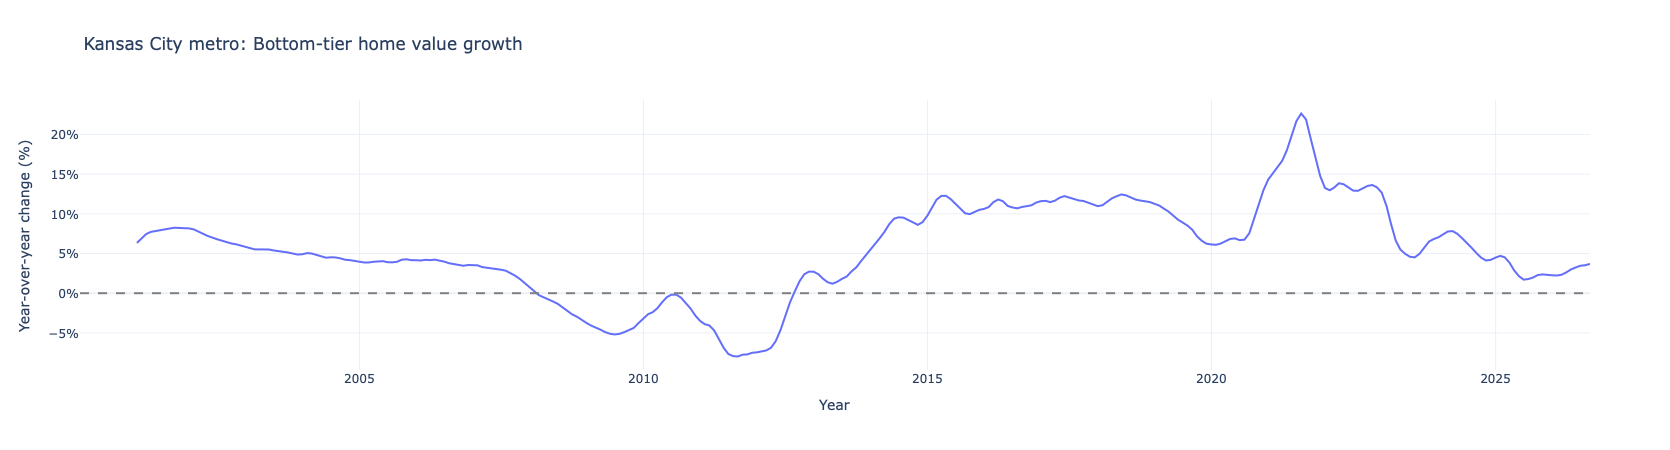

In [10]:
# Compare each month with the same month one year earlier.
kc_monthly["yoy_pct"] = (
    kc_monthly["bottom_tier_zhvi"]
    .pct_change(periods=12, fill_method=None)
    .mul(100)
)

# Find the month with the largest year-over-year percentage increase.
fastest = kc_monthly.loc[kc_monthly["yoy_pct"].idxmax()]

print(
    f"Largest year-over-year increase: {fastest['yoy_pct']:.1f}% "
    f"in {fastest['date']:%B %Y}"
)

fig_growth = px.line(
    kc_monthly,
    x="date",
    y="yoy_pct",
    title="Kansas City metro: Bottom-tier home value growth",
    labels={"date": "Year", "yoy_pct": "Year-over-year change (%)"},
    template="plotly_white"
)

fig_growth.add_hline(y=0, line_dash="dash", line_color="gray")
fig_growth.update_layout(yaxis_ticksuffix="%", height=450)
fig_growth.show()

In [11]:
# Summarize monthly values by calendar year.
kc_annual = (
    kc_monthly.assign(year=kc_monthly["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        avg_bottom_tier_zhvi=("bottom_tier_zhvi", "mean"),
        months_available=("bottom_tier_zhvi", "count")
    )
)

comparison = kc_annual.loc[
    kc_annual["year"].isin([2019, 2024])
].copy()

assert len(comparison) == 2, "Both comparison years must be present."
assert comparison["months_available"].eq(12).all(), (
    "Each comparison year must have 12 monthly values."
)

display(comparison.round({"avg_bottom_tier_zhvi": 0}))

values = comparison.set_index("year")["avg_bottom_tier_zhvi"]
dollar_change = values.loc[2024] - values.loc[2019]
percent_change = (values.loc[2024] / values.loc[2019] - 1) * 100

print(f"Increase in annual-average value: ${dollar_change:,.0f}")
print(f"Percentage increase, 2019–2024: {percent_change:.1f}%")

,year,avg_bottom_tier_zhvi,months_available
19,2019,113478.0,12
24,2024,185359.0,12


Increase in annual-average value: $71,881
Percentage increase, 2019–2024: 63.3%


## Review of saved outputs

| Observation | Verification level |
|---|---|
| 320 Kansas City months, January 2000–August 2026; no missing values or duplicate months | Checked against the series embedded in the saved chart |
| Lowest value in the **2011–2014 window**: March 2012, about USD 59,537 | Recalculated from the saved series; not a claim about the entire history |
| April 2013 value: about USD 60,324 | Recalculated from the saved series; April is not the window's minimum |
| Largest YoY increase: 22.6% in July 2021 | Recalculated with a 12-month lag; calendar continuity checked |
| Annual-average value change, 2019–2024: 63.3%, with 12 months in each year | Recalculated from saved series; nominal and descriptive |

These checks verify internal consistency only. The original source bytes, checksum, adjustment settings, all four selected geographies, and a clean full rerun are still needed for source-verified release results. A rise after a reference month does not identify the reason for the rise.


## Archived exploratory appendix — excluded from version 1 findings

The original local workbook also contained Kansas City ACS income, mortgage payment, model decomposition, and down-payment experiments for 2019 / 2024. They are retained to preserve completed work, **not to extend the repository research question**. Their saved outputs are unverified exploratory artifacts and are not promoted into project findings. No causal explanation of actual market changes follows from a model decomposition.

Appendix execution is disabled by default. Running version 1 requires only the Zillow snapshot. Setting `RUN_ARCHIVED_APPENDIX = True` explicitly opts into the archived experiments, which request Census and FRED data and write local working files. Live responses may differ from the saved historical outputs. Use the retained raw responses to verify the historical run before interpreting them.

The model assumes a 30-year loan and 10% down (3% / 20% alternatives); principal and interest exclude taxes, insurance, PMI, HOA fees, closing costs, and maintenance. General metro median income is not first-time-buyer income. ACS margins of error are displayed but not propagated. No affordability or causal conclusion is accepted in version 1 from this appendix.


In [ ]:
RUN_ARCHIVED_APPENDIX = False


In [12]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    from getpass import getpass
    
    CENSUS_API_KEY = getpass("Paste you Census API Key").strip()


Paste you Census API Key ········


In [27]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    import requests
    import json
    from datetime import date
    
    # Preserve the original Census responses.
    CENSUS_DIR = (
        PROJECT_ROOT / "data" / "raw" / "census" / date.today().isoformat()
    )
    CENSUS_DIR.mkdir(parents=True, exist_ok=True)
    
    geography = "metropolitan statistical area/micropolitan statistical area"
    income_tables = []
    
    for year in [2019, 2024]:
        url = f"https://api.census.gov/data/{year}/acs/acs1"
    
        params = {
            "get": "NAME,B19013_001E,B19013_001M",
            "for": f"{geography}:28140",
            "key": CENSUS_API_KEY
        }
    
        # Keep request errors from displaying a URL containing the key.
        try:
            response = requests.get(url, params=params, timeout=30)
        except requests.RequestException:
            raise RuntimeError(f"Census connection failed for {year}.") from None
    
        if response.status_code != 200:
            raise RuntimeError(
                f"Census returned HTTP {response.status_code} for {year}."
            )
    
        try:
            payload = response.json()
        except ValueError:
            raise RuntimeError(
                f"Census did not return JSON for {year}. Check key activation."
            ) from None
    
        if not isinstance(payload, list) or len(payload) != 2:
            raise ValueError(f"Expected one metro record for {year}.")
    
        # Save the data response; the API key is not included.
        output_file = CENSUS_DIR / f"acs1_{year}_kc_income.json"
        output_file.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    
        table = pd.DataFrame(payload[1:], columns=payload[0])
        table["year"] = year
        income_tables.append(table)
    
    income = pd.concat(income_tables, ignore_index=True)


In [29]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    income = income.rename(columns={
        "NAME": "metro_name",
        "B19013_001E": "median_household_income",
        "B19013_001M": "income_margin_of_error",
        geography: "cbsa_code"
    })
    
    for column in ["median_household_income", "income_margin_of_error"]:
        income[column] = pd.to_numeric(income[column], errors="raise")
        income.loc[income[column] < 0, column] = float("nan")
    
    display(income[[
        "year",
        "metro_name",
        "cbsa_code",
        "median_household_income",
        "income_margin_of_error"
    ]])


,year,metro_name,cbsa_code,median_household_income,income_margin_of_error
0,2019,"Kansas City, MO-KS Metro Area",28140,70215.0,1212.0
1,2024,"Kansas City, MO-KS Metro Area",28140,83785.0,1719.0


In [31]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    # Each table contains one Kansas City observation per year.
    kc_affordability = kc_annual.loc[
        kc_annual["year"].isin([2019, 2024])
    ].merge(
        income,
        on="year",
        how="left",
        validate="one_to_one"
    )
    
    assert kc_affordability["median_household_income"].gt(0).all(), (
        "Each year needs a valid, positive income estimate."
    )
    
    kc_affordability["value_to_income"] = (
        kc_affordability["avg_bottom_tier_zhvi"]
        / kc_affordability["median_household_income"]
    )
    
    display(
        kc_affordability[[
            "year",
            "avg_bottom_tier_zhvi",
            "median_household_income",
            "value_to_income"
        ]].round({
            "avg_bottom_tier_zhvi": 0,
            "median_household_income": 0,
            "value_to_income": 2
        })
    )


,year,avg_bottom_tier_zhvi,median_household_income,value_to_income
0,2019,113478.0,70215.0,1.62
1,2024,185359.0,83785.0,2.21


In [33]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    from io import BytesIO
    
    RATE_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
    
    response = requests.get(RATE_URL, timeout=30)
    response.raise_for_status()
    
    rates = pd.read_csv(BytesIO(response.content), na_values=".")
    
    assert "MORTGAGE30US" in rates.columns, "Unexpected download format."
    
    # Standardize the date and rate column names.
    rates = rates.rename(columns={
        rates.columns[0]: "date",
        "MORTGAGE30US": "mortgage_rate_pct"
    })
    
    rates["date"] = pd.to_datetime(rates["date"])
    rates["mortgage_rate_pct"] = pd.to_numeric(
        rates["mortgage_rate_pct"], errors="raise"
    )
    
    # Save the original download for reproducibility.
    RATE_DIR = PROJECT_ROOT / "data" / "raw" / "fred" / date.today().isoformat()
    RATE_DIR.mkdir(parents=True, exist_ok=True)
    (RATE_DIR / "MORTGAGE30US.csv").write_bytes(response.content)
    
    display(rates.head())


,date,mortgage_rate_pct
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [35]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    rates["month"] = rates["date"].dt.to_period("M")
    
    monthly_rates = (
        rates.groupby("month", as_index=False)
        .agg(
            mortgage_rate_pct=("mortgage_rate_pct", "mean"),
            weekly_observations=("mortgage_rate_pct", "count")
        )
    )
    
    monthly_rates["year"] = monthly_rates["month"].dt.year
    
    pilot_rates = monthly_rates.loc[
        monthly_rates["year"].isin([2019, 2024])
    ].copy()
    
    assert len(pilot_rates) == 24, "Expected 12 months for each year."
    assert pilot_rates["weekly_observations"].ge(4).all(), (
        "At least one month has fewer than four valid weekly observations."
    )
    
    display(pilot_rates.round({"mortgage_rate_pct": 2}))


,month,mortgage_rate_pct,weekly_observations,year
573,2019-01,4.46,5,2019
574,2019-02,4.37,4,2019
575,2019-03,4.26,4,2019
576,2019-04,4.14,4,2019
577,2019-05,4.07,5,2019
578,2019-06,3.80,4,2019
579,2019-07,3.76,4,2019
580,2019-08,3.62,5,2019
581,2019-09,3.60,4,2019
582,2019-10,3.69,5,2019


In [37]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    payment_model = kc_monthly.loc[
        kc_monthly["date"].dt.year.isin([2019, 2024])
    ].copy()
    
    payment_model["month"] = payment_model["date"].dt.to_period("M")
    payment_model["year"] = payment_model["date"].dt.year
    
    payment_model = payment_model.merge(
        pilot_rates[["month", "mortgage_rate_pct"]],
        on="month",
        how="left",
        validate="one_to_one"
    )
    
    assert len(payment_model) == 24
    assert payment_model["mortgage_rate_pct"].gt(0).all()
    assert payment_model["bottom_tier_zhvi"].gt(0).all()


In [39]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    DOWN_PAYMENT_PCT = 0.10
    LOAN_YEARS = 30
    
    payment_model["loan_amount"] = (
        payment_model["bottom_tier_zhvi"] * (1 - DOWN_PAYMENT_PCT)
    )
    
    # Convert annual percentage rates into monthly decimal rates.
    monthly_rate = payment_model["mortgage_rate_pct"] / 100 / 12
    number_of_payments = LOAN_YEARS * 12
    
    payment_model["monthly_pi"] = (
        payment_model["loan_amount"]
        * monthly_rate
        / (1 - (1 + monthly_rate) ** (-number_of_payments))
    )


In [41]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    payment_summary = (
        payment_model.groupby("year", as_index=False)
        .agg(
            avg_monthly_pi=("monthly_pi", "mean"),
            months_available=("monthly_pi", "count")
        )
        .merge(
            income[["year", "median_household_income"]],
            on="year",
            how="left",
            validate="one_to_one"
        )
    )
    
    assert payment_summary["months_available"].eq(12).all()
    assert payment_summary["median_household_income"].gt(0).all()
    
    payment_summary["pi_share_of_income_pct"] = (
        payment_summary["avg_monthly_pi"]
        / (payment_summary["median_household_income"] / 12)
        * 100
    )
    
    display(payment_summary.round({
        "avg_monthly_pi": 2,
        "median_household_income": 0,
        "pi_share_of_income_pct": 1
    }))


,year,avg_monthly_pi,months_available,median_household_income,pi_share_of_income_pct
0,2019,483.66,12,70215.0,8.3
1,2024,1079.16,12,83785.0,15.5


In [43]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    results = payment_summary.set_index("year")
    
    payment_growth = (
        results.loc[2024, "avg_monthly_pi"]
        / results.loc[2019, "avg_monthly_pi"] - 1
    ) * 100
    
    income_growth = (
        results.loc[2024, "median_household_income"]
        / results.loc[2019, "median_household_income"] - 1
    ) * 100
    
    burden_change_pp = (
        results.loc[2024, "pi_share_of_income_pct"]
        - results.loc[2019, "pi_share_of_income_pct"]
    )
    
    print(f"Modeled payment increase: {payment_growth:.1f}%")
    print(f"Median household income increase: {income_growth:.1f}%")
    print(f"Payment burden increase: {burden_change_pp:.1f} percentage points")


Modeled payment increase: 123.1%
Median household income increase: 19.3%
Payment burden increase: 7.2 percentage points


In [45]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    CHECKPOINT_DIR = PROJECT_ROOT / "data" / "interim"
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    
    payment_model.to_csv(
        CHECKPOINT_DIR / "kc_monthly_payment_model.csv", index=False
    )
    
    payment_summary.to_csv(
        CHECKPOINT_DIR / "kc_payment_summary.csv", index=False
    )
    
    kc_affordability.to_csv(
        CHECKPOINT_DIR / "kc_value_income_comparison.csv", index=False
    )
    
    print("Saved three working tables.")


Saved three working tables.


In [47]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    import pandas as pd
    import numpy as np
    from pathlib import Path
    
    # Reuse PROJECT_ROOT from the Zillow section.
    
    payment_model = pd.read_csv(
        PROJECT_ROOT / "data" / "interim" / "kc_monthly_payment_model.csv",
        parse_dates=["date"]
    )
    
    payment_model["month_number"] = payment_model["date"].dt.month
    
    base = (
        payment_model.loc[payment_model["year"].eq(2019)]
        .set_index("month_number")
        .sort_index()
    )
    
    current = (
        payment_model.loc[payment_model["year"].eq(2024)]
        .set_index("month_number")
        .sort_index()
    )
    
    assert base.index.tolist() == list(range(1, 13))
    assert current.index.tolist() == list(range(1, 13))


In [49]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    def monthly_pi(home_value, annual_rate_pct):
        principal = home_value * 0.90
        monthly_rate = annual_rate_pct / 100 / 12
        assert monthly_rate.gt(0).all()
    
        return principal * monthly_rate / (
            1 - (1 + monthly_rate) ** -360
        )
    
    
    p00 = monthly_pi(
        base["bottom_tier_zhvi"], base["mortgage_rate_pct"]
    ).mean()
    
    p10 = monthly_pi(
        current["bottom_tier_zhvi"], base["mortgage_rate_pct"]
    ).mean()
    
    p01 = monthly_pi(
        base["bottom_tier_zhvi"], current["mortgage_rate_pct"]
    ).mean()
    
    p11 = monthly_pi(
        current["bottom_tier_zhvi"], current["mortgage_rate_pct"]
    ).mean()
    
    # Confirm we reproduce the original model.
    assert np.isclose(p00, base["monthly_pi"].mean())
    assert np.isclose(p11, current["monthly_pi"].mean())
    
    scenarios = pd.DataFrame({
        "scenario": [
            "2019 baseline",
            "Only home values change",
            "Only mortgage rates change",
            "2024 comparison"
        ],
        "avg_monthly_pi": [p00, p10, p01, p11]
    })
    
    display(scenarios.round({"avg_monthly_pi": 2}))


,scenario,avg_monthly_pi
0,2019 baseline,483.66
1,Only home values change,790.02
2,Only mortgage rates change,660.70
3,2024 comparison,1079.16


In [51]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    value_contribution = ((p10 - p00) + (p11 - p01)) / 2
    rate_contribution = ((p01 - p00) + (p11 - p10)) / 2
    total_increase = p11 - p00
    
    assert np.isclose(
        value_contribution + rate_contribution,
        total_increase
    )
    
    contributions = pd.DataFrame({
        "factor": ["Home values", "Mortgage rates"],
        "monthly_dollar_contribution": [
            value_contribution, rate_contribution
        ]
    })
    
    contributions["share_of_increase_pct"] = (
        contributions["monthly_dollar_contribution"] / total_increase * 100
    )
    
    display(contributions.round(2))
    print(f"Total monthly payment increase: ${total_increase:,.2f}")


,factor,monthly_dollar_contribution,share_of_increase_pct
0,Home values,362.41,60.86
1,Mortgage rates,233.09,39.14


Total monthly payment increase: $595.50


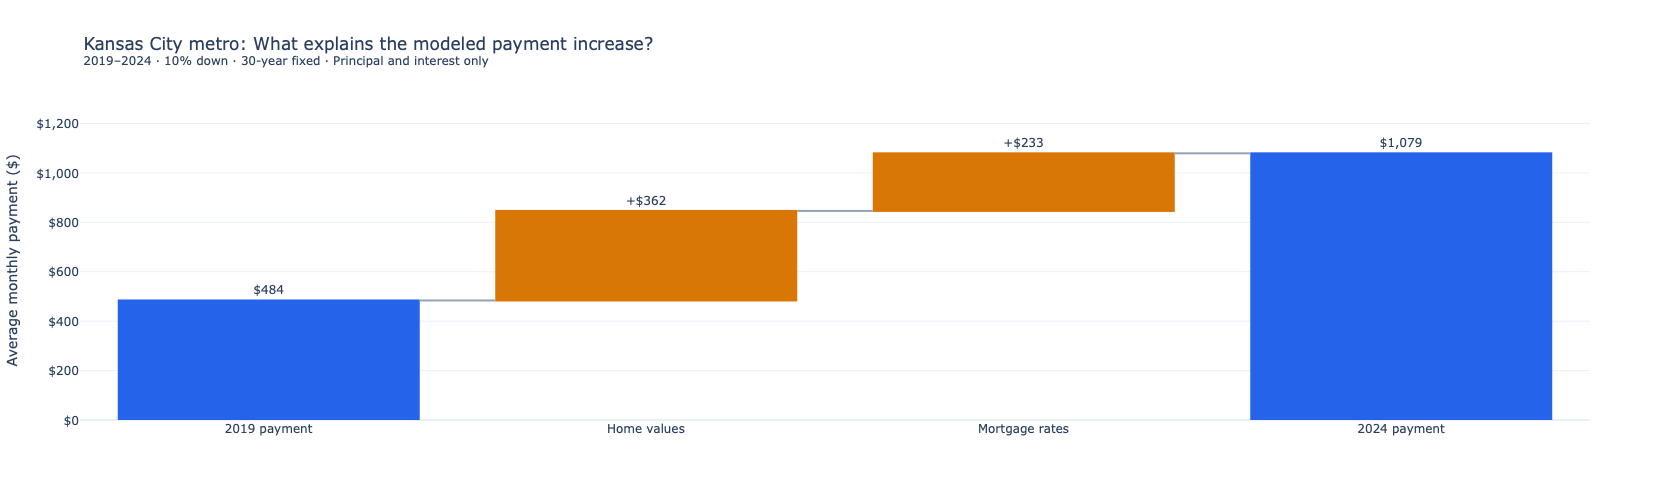

In [53]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    import plotly.graph_objects as go
    
    fig_decomposition = go.Figure(go.Waterfall(
        orientation="v",
        measure=["absolute", "relative", "relative", "total"],
        x=[
            "2019 payment",
            "Home values",
            "Mortgage rates",
            "2024 payment"
        ],
        y=[p00, value_contribution, rate_contribution, 0],
        text=[
            f"${p00:,.0f}",
            f"+${value_contribution:,.0f}",
            f"+${rate_contribution:,.0f}",
            f"${p11:,.0f}"
        ],
        textposition="outside",
        connector={"line": {"color": "#94A3B8"}},
        increasing={"marker": {"color": "#D97706"}},
        totals={"marker": {"color": "#2563EB"}}
    ))
    
    fig_decomposition.update_layout(
        title=(
            "Kansas City metro: What explains the modeled payment increase?"
            "<br><sup>2019–2024 · 10% down · 30-year fixed · "
            "Principal and interest only</sup>"
        ),
        yaxis_title="Average monthly payment ($)",
        yaxis_tickprefix="$",
        yaxis_tickformat=",",
        yaxis_range=[0, p11 * 1.20],
        template="plotly_white",
        showlegend=False,
        height=500
    )
    
    fig_decomposition.show()


In [55]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    
    INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
    INTERIM_DIR.mkdir(parents=True, exist_ok=True)
    
    fig_decomposition.write_html(
        FIGURE_DIR / "kc_payment_decomposition.html",
        include_plotlyjs=True
    )
    
    scenarios.to_csv(INTERIM_DIR / "kc_payment_scenarios.csv", index=False)
    contributions.to_csv(
        INTERIM_DIR / "kc_payment_contributions.csv", index=False
    )
    
    print("Saved the interactive chart and both tables.")


Saved the interactive chart and both tables.


In [57]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    scenario_tables = []
    
    for down_pct in [0.03, 0.10, 0.20]:
        scenario = payment_model.copy()
    
        scenario["down_payment"] = scenario["bottom_tier_zhvi"] * down_pct
        loan = scenario["bottom_tier_zhvi"] * (1 - down_pct)
        rate = scenario["mortgage_rate_pct"] / 100 / 12
    
        scenario["monthly_pi"] = (
            loan * rate / (1 - (1 + rate) ** -360)
        )
    
        annual = (
            scenario.groupby("year", as_index=False)
            .agg(
                avg_down_payment=("down_payment", "mean"),
                avg_monthly_pi=("monthly_pi", "mean")
            )
        )
    
        annual["down_payment_pct"] = down_pct * 100
        scenario_tables.append(annual)
    
    down_payment_comparison = (
        pd.concat(scenario_tables, ignore_index=True)
        .sort_values(["year", "down_payment_pct"])
    )
    
    display(
        down_payment_comparison[[
            "year",
            "down_payment_pct",
            "avg_down_payment",
            "avg_monthly_pi"
        ]].round(2)
    )


,year,down_payment_pct,avg_down_payment,avg_monthly_pi
0,2019,3.0,3404.33,521.28
2,2019,10.0,11347.76,483.66
4,2019,20.0,22695.53,429.92
1,2024,3.0,5560.76,1163.09
3,2024,10.0,18535.86,1079.16
5,2024,20.0,37071.71,959.25


In [59]:
# Archived exploratory code; saved outputs are not release findings.
if RUN_ARCHIVED_APPENDIX:
    # Restore the saved income figures without repeating the API request.
    saved_income = pd.read_csv(
        PROJECT_ROOT / "data" / "interim" / "kc_payment_summary.csv"
    )[["year", "median_household_income"]]
    
    scenario_summary = down_payment_comparison.merge(
        saved_income,
        on="year",
        how="left",
        validate="many_to_one"
    )
    
    assert scenario_summary["median_household_income"].gt(0).all()
    
    scenario_summary["down_payment_share_of_annual_income_pct"] = (
        scenario_summary["avg_down_payment"]
        / scenario_summary["median_household_income"] * 100
    )
    
    scenario_summary["pi_share_of_monthly_income_pct"] = (
        scenario_summary["avg_monthly_pi"]
        / (scenario_summary["median_household_income"] / 12) * 100
    )
    
    display(scenario_summary.round(2))
    
    scenario_summary.to_csv(
        PROJECT_ROOT / "data" / "interim" / "kc_down_payment_scenarios.csv",
        index=False
    )


,year,avg_down_payment,avg_monthly_pi,down_payment_pct,median_household_income,down_payment_share_of_annual_income_pct,pi_share_of_monthly_income_pct
0,2019,3404.33,521.28,3.0,70215.0,4.85,8.91
1,2019,11347.76,483.66,10.0,70215.0,16.16,8.27
2,2019,22695.53,429.92,20.0,70215.0,32.32,7.35
3,2024,5560.76,1163.09,3.0,83785.0,6.64,16.66
4,2024,18535.86,1079.16,10.0,83785.0,22.12,15.46
5,2024,37071.71,959.25,20.0,83785.0,44.25,13.74
